<a href="https://colab.research.google.com/github/KishoreKumar477/ml-supervised/blob/main/titanicds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'titanic-dataset' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.38383

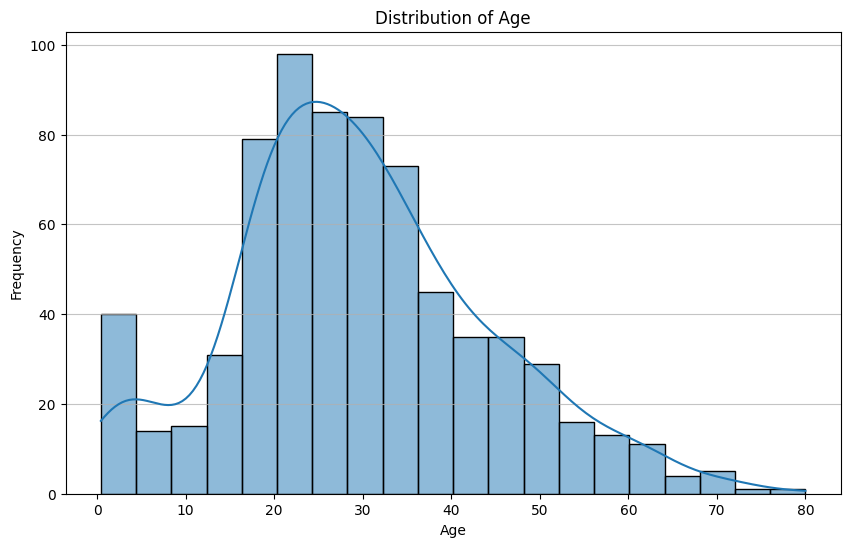

Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667


In [156]:
import kagglehub, pandas as pd, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score


path = kagglehub.dataset_download("yasserh/titanic-dataset")
df = pd.read_csv(os.path.join(path, "Titanic-Dataset.csv"))
df.head()

print(df.info())
print(df.describe())

print(df.shape)
print(df['Survived'].value_counts())

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Distribution of Age'); plt.xlabel('Age'); plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75); plt.show()


df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)
df['Sex']      = df['Sex'].map({"male": 0, "female": 1})
df['Embarked'] = df['Embarked'].map({"S": 0, "C": 1, "Q": 2})

X = df.drop(["Survived", "PassengerId"], axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

'''preventing overfitting by separate filling of
 na datapoints so that the model does not know the
 statistical insight of test data as well'''
for dataset in [X_train, X_test]:
    dataset['Fare']     = dataset['Fare'].fillna(X_train['Fare'].median())
    dataset['Age']      = dataset['Age'].fillna(X_train['Age'].median())
    dataset['Embarked'] = dataset['Embarked'].fillna(X_train['Embarked'].mode()[0])

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")

